In [33]:
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt



# Setting up the environment :
Loading images


In [34]:
import tifffile
import cv2
import os

# Chemins d'accès
images_path = "data/data1/D1-1M-sample1-hydrogel.tif"
masks_path = "data/data1/D1-1M-sample1-spheroid.tif"
output_folder = "images"

def export_slice(index):
    global images_path, masks_path, output_folder

    # Extraire le nom du dossier parent (data1 → i=1)
    data_i = os.path.basename(os.path.dirname(images_path))  # ex: 'data1'

    # Préfixe pour le nom de fichier
    prefix = f"{data_i}_"

    # Fichiers de sortie
    image_filename = f"{prefix}image_{index}.png"
    mask_filename = f"{prefix}mask_{index}.png"

    # Charger les stacks
    large_images = tifffile.imread(images_path)
    large_masks = tifffile.imread(masks_path)

    # Extraire l'image et le masque à l'index donné
    image_i = large_images[index]
    mask_i = large_masks[index]

    # Créer le dossier de sortie si nécessaire
    os.makedirs(output_folder, exist_ok=True)

    # Fonction de normalisation en uint8
    def normalize_to_uint8(img):
        if img.dtype == 'uint8':
            return img
        return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

    # Normaliser et sauvegarder
    image_i = normalize_to_uint8(image_i)
    mask_i = normalize_to_uint8(mask_i)

    cv2.imwrite(os.path.join(output_folder, image_filename), image_i)
    cv2.imwrite(os.path.join(output_folder, mask_filename), mask_i)

    print(f"[✔] Image sauvegardée dans {output_folder}/{image_filename}")
    print(f"[✔] Masque sauvegardé dans {output_folder}/{mask_filename}")

Shaping the image into a relevant 256*256 pixels format

In [35]:
from PIL import Image
from patchify import patchify

def shape_image(image_path, mask_path, patch_size = 256, step = 128):
    
    image = Image.open(image_path)
    mask = Image.open(mask_path)

    #Desired patch size for smaller images and step size.

    image_array = np.array(image)  # Convert PIL Image to NumPy array
    mask_array = np.array(mask)    # Convert PIL Image to NumPy array

    patches_img = patchify(image_array, (patch_size, patch_size), step=step)  # Step=128 for 128 patches means there will be overlap
    patches_mask = patchify(mask_array, (patch_size, patch_size), step=step)  # Step=128 for 128 patches means there will be overlap    

    all_img_patches = []
    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):

            single_patch_img = patches_img[i,j,:,:]
            all_img_patches.append(single_patch_img)
    images = np.array(all_img_patches)
    

    all_mask_patches = []
    for i in range(patches_mask.shape[0]):
        for j in range(patches_mask.shape[1]):

            single_patch_mask = patches_mask[i,j,:,:]
            all_mask_patches.append(single_patch_mask)
    masks = np.array(all_mask_patches)

    #look for the best patch with the most organoid in it.
    max_i=0
    for i in range(len(masks)):
        if np.count_nonzero(masks[i][10:-10][10:-10]) > np.count_nonzero(masks[max_i][10:-10][10:-10]):
            max_i=i
    
    patch_image = images[max_i]
    patch_mask = masks[max_i]

    return patch_image, patch_mask

def initialize_image(index):
    # Index de l'image/mask à extraire
    export_slice(index)

    # Charger les images (adapter les chemins)
    image_path = f"images/data1_image_{index}.png" 
    mask_path = f"images/data1_mask_{index}.png"

    # 1. Charger les images
    image, mask = shape_image(image_path, mask_path, patch_size=256, step=128)
    
    return image, mask

index = 400
image, mask = initialize_image(index)


[✔] Image sauvegardée dans images/data1_image_400.png
[✔] Masque sauvegardé dans images/data1_mask_400.png


Adding a function to visually compare 2 images

In [36]:
def compare_images(im1, im2):
    #plt.imshow(cv2.cvtColor(im1, cv2.COLOR_BGR2RGB))

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, image 1
    plt.imshow(im1, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)  # image 2
    plt.imshow(im2, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

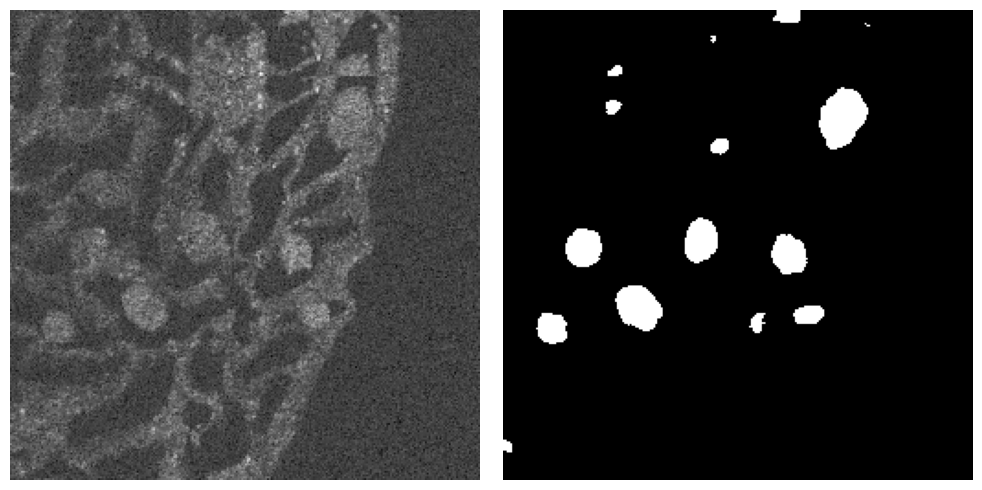

In [37]:
compare_images(image,mask)

Listing the available computervision algorithms

In [38]:
from sklearn.metrics import f1_score
print("scikit-learn installed successfully")


scikit-learn installed successfully


# Environment : 
une box
action = choisir une séquence d'algo et les appliquer à la box (output)
reward = f1(score) sur l'image output
policy-update

In [56]:
class Environment_2:
    def __init__(self,image,mask,algo_sequence,prediction=None,keep_sequence=False,parameters=None):
        self.image=image
        self.mask=mask
        self.algo_sequence=algo_sequence
        self.prediction=prediction
        self.keep_sequence=keep_sequence
        self.predictions=[]
        self.parameters=parameters 

    def apply_computer_vision_sequence(self,chosen_sequence, keep_sequence):
        image = self.image
        
        if keep_sequence:
            images = [image]

        # Loop through the algorithm sequence

        for i in range(len(chosen_sequence)):
            algo_name = chosen_sequence[i]

            func = ALGO_REGISTRY[algo_name]["func"]
            parameter = self.parameters[algo_name] if self.parameters else ALGO_REGISTRY[algo_name]["params"]

            # Apply the algorithm to the image
            image=func(image, **parameter)
            if keep_sequence:
                self.predictions.append(image)        
        
        return image  

    def reward(self,prediction,threshold=128):
            mask = self.mask

            pred_flat = prediction.flatten()
            mask_flat = mask.flatten()

            # Binarize if necessary
            if pred_flat.max() > 1:
                pred_flat = (pred_flat >= threshold).astype(np.uint8)
            if mask_flat.max() > 1:
                mask_flat = (mask_flat >= threshold).astype(np.uint8)

            # Compute the F1-score
            score = f1_score(mask_flat, pred_flat, zero_division=0)
            return score
    
    def show_seq(self,indexes):
        if self.keep_sequence:
            plt.figure(figsize=(3 * len(indexes), 4))  # 🔍 Ajuste la taille ici
            for i, image in enumerate(self.predictions):
                if i in indexes:
                    plt.subplot(1, len(indexes), i + 1)
                    plt.imshow(image, cmap='gray')
                    plt.axis('off')
            plt.show()
        else:
            print("No sequence to show. Set keep_sequence=True when applying the algorithm sequence.")

    def show_last(self):
        compare_images(self.predictions[-1], self.image)
        return self.predictions[-1]

# Combined Bandit Agent

In [40]:
class CombinedBanditAgent():
    def __init__(self, algo_list, depth=1,epsilon=0.1):
        self.algo_list = algo_list
        self.count_algo = len(algo_list)
        self.all_algo_sequences = list(itertools.product(algo_list, repeat=depth))
        self.count_algo_sequences = len(self.all_algo_sequences)
        self.values = np.zeros(len(self.all_algo_sequences))
        self.pullCount = np.zeros(len(self.all_algo_sequences))
        self.choice = np.arange(self.count_algo)
        self.depth = depth
        self.algo_count = len(algo_list)
        self.epsilon = epsilon
        
    def __repr__(self):
        return "CombinedBandit"

    def selectArm(self):
        if np.random.rand() > self.epsilon: # Exploit
            vMax = max(self.values)
            return np.random.choice(np.flatnonzero(self.values == vMax))
        else: # Explore
            return np.random.choice(self.count_algo_sequences)

    def update(self, i, reward):
        self.pullCount[i] += 1
        count = self.pullCount[i]
        value = self.values[i]
        self.values[i] = value + (1/count) * (reward - value)

    def refresh(self):
        self.values.fill(0)
        self.pullCount.fill(0)

# Block Bandit Softmax Agent

In [41]:
from collections import defaultdict

class BlockBanditSoftmaxAgent:
    def __init__(self, blocks, max_blocks_per_seq=3, temperature=1.0):
        """
        max_blocks_per_seq: max number of blocks per sequence
        temperature: softmax temperature τ
        """
        blocks=[(block,) for block in blocks]  # Ensure all blocks are tuples
        
        self.blocks = blocks
        self.max_blocks = max_blocks_per_seq
        self.tau = temperature

        self.block_values = defaultdict(float)  # mean reward per block
        self.counts = defaultdict(int)          # how many times each block used
        self.seen_sequences = set()             # memory of sequences tried

    def _softmax_probs(self):
        q_values = np.array([self.block_values[b] for b in self.blocks])
        scaled = q_values / self.tau
        exp_q = np.exp(scaled - np.max(scaled))  # stability trick
        probs = exp_q / np.sum(exp_q)
        return probs

    def select_action_sequence(self):
        """
        Generate a unique sequence using softmax sampling and memory check
        """
        attempt = 0
        while attempt < 1000:  # limit attempts to find unseen sequence to avoid infinite loop
            sequence = []
            for i in range(self.max_blocks):
                probs = self._softmax_probs()
                block = self.blocks[np.random.choice(len(self.blocks), p=probs)]
                sequence.extend(block)
                if "STOP" in block:
                    break
            seq_tuple = tuple(sequence)
            if seq_tuple not in self.seen_sequences:
                self.seen_sequences.add(seq_tuple)
                return seq_tuple
            attempt += 1
        raise RuntimeError("Unable to generate new sequence after many attempts")

    def update(self, sequence, reward):
        """
        Update Q-values for blocks that appeared in the sequence
        """
        for block in self.blocks:
            if self._block_in_sequence(block, sequence):
                self.counts[block] += 1
                alpha = 1 / self.counts[block]
                self.block_values[block] += alpha * (reward - self.block_values[block])

    def _block_in_sequence(self, block, sequence):
        """
        Returns True if block appears as a subsequence in sequence
        """
        b_len = len(block)
        return any(tuple(sequence[i:i+b_len]) == block for i in range(len(sequence) - b_len + 1))

    def refresh(self):
        """
        Reset learning and memory
        """
        self.block_values.clear()
        self.counts.clear()
        self.seen_sequences.clear()

    def get_known_blocks(self):
        return list(self.block_values.keys())
    
    def add_to_history(self, sequence, reward):
        if not hasattr(self, "history"):
            self.history = []
        self.history.append((sequence, reward))

    def update_blocks_from_history(self, n_range=(1, 3), top_k=10):
        """
        Update self.blocks from best scoring n-grams in history
        """
        from collections import defaultdict

        block_scores = defaultdict(list)

        for sequence, reward in getattr(self, "history", []):
            length = len(sequence)
            for n in range(n_range[0], n_range[1] + 1):
                for i in range(length - n + 1):
                    block = tuple(sequence[i:i+n])
                    block_scores[block].append(reward)

        # Compute average reward per block
        avg_scores = {block: sum(scores) / len(scores) for block, scores in block_scores.items()}
        # Keep top-K blocks
        top_blocks = sorted(avg_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        self.blocks = [block for block, _ in top_blocks]

        # Reset values related to blocks
        self.block_values = defaultdict(float)
        self.counts = defaultdict(int)
        self.seen_sequences = set()
    
    def get_block_values(self):
        
        data=self.block_values.copy()
        top_10 = sorted(data.items(), key=lambda x: x[1], reverse=True)[:10]
        print("Top 10 blocks and their values:")
        for key, value in top_10:
            print(f"Key: {key}, Value: {value}")
        return top_10
    
    
    

Réécriture blockbanditsoftmaxagent


In [ ]:
from collections import defaultdict

class BlockBanditSoftmaxAgent:
    def __init__(self, blocks, max_blocks_per_seq=3, temperature=1.0):
        """
        max_blocks_per_seq: max number of blocks per sequence
        temperature: softmax temperature τ
        """
        self.blocks={}
        i=0
        for block in blocks:
            i+=1
            params = ALGO_REGISTRY[block]["params"]
            self.blocks[f"{i}"] = {"sequence": {block: {"params" : params }},"f1-score" : 0, "seen" : 0, "length" : 1 }
        
       # self.blocks={"block_1":{"algo_1":{"params" : {"aze", }, "f1-score" : 0.5,"prob": 0.2, "seen" : 0, }}}

        self.max_blocks = max_blocks_per_seq
        self.tau = temperature

        
    def _softmax_probs(self):

        q_values = np.array([self.blocks[b]["f1-score"] for b in self.blocks.keys()])
        scaled = q_values / self.tau
        exp_q = np.exp(scaled - np.max(scaled))  # stability trick
        probs = exp_q / np.sum(exp_q)
        return probs
    
    def create_new_block(self,probs):
        
        block_1 = self.blocks[np.random.choice(len(self.blocks), p=probs)]
        found_block_2=False
        if len(block_1) == self.max_blocks:
            block_2=None
            found_block_2=True
        
        while not found_block_2:
            
            block_2 = self.blocks[np.random.choice(len(self.blocks), p=probs)]
            if block_2["length"] < self.max_blocks - block_1["length"]:
                found_block_2=True

        if block_2 = None:
        
        # Check if the new block already exists
        if new_block not in self.blocks:
            self.blocks.append(new_block)

        return new_block
    
    def select_action_sequence(self):
        probs = self._softmax_probs()
        new_block = self.create_new_block(probs)
        length_seq = len(new_block)
        while length_seq < self.max_blocks:
            possible_blocks = self.blocks[np.random.choice(len(self.blocks), p=probs)]
            new_block.extend(block)
            length_seq += len(block)
            if "STOP" in block:
                break
    
        

        """
        Create a new block by combining existing blocks
        """
        new_block = []
        for i in range(self.max_blocks):
            
            block = self.blocks[np.random.choice(len(self.blocks), p=probs)]
            new_block.extend(block)
            if "STOP" in block:
                break
        return tuple(new_block)


    def select_action_sequence2(self):
        """
        Generate a unique sequence using softmax sampling and memory check
        """
        attempt = 0
        while attempt < 1000:  # limit attempts to find unseen sequence to avoid infinite loop
            sequence = []
            for i in range(self.max_blocks):
                probs = self._softmax_probs()
                block = self.blocks[np.random.choice(len(self.blocks), p=probs)]
                sequence.extend(block)
                if "STOP" in block:
                    break
            seq_tuple = tuple(sequence)
            if seq_tuple not in self.seen_sequences:
                self.seen_sequences.add(seq_tuple)
                return seq_tuple
            attempt += 1
        raise RuntimeError("Unable to generate new sequence after many attempts")
    
    def select_action_sequence(self):
        """
        Generate a unique sequence using softmax sampling and memory check
        """
        sequence = []
        length_seq=0
        probs = self._softmax_probs()

        while length_seq < self.max_blocks:
            block1 = self.blocks[np.random.choice(len(self.blocks), p=probs)]
            block2 = self.blocks[np.random.choice(len(self.blocks), p=probs)]

        for i in range(self.max_blocks):
            probs = self._softmax_probs()
            block = self.blocks[np.random.choice(len(self.blocks), p=probs)]
            sequence.extend(block)
            if "STOP" in block:
                break
        seq_tuple = tuple(sequence)
        if seq_tuple not in self.seen_sequences:
            self.seen_sequences.add(seq_tuple)
            return seq_tuple
        

    def update(self, sequence, reward):
        """
        Update Q-values for blocks that appeared in the sequence
        """
        for block in self.blocks:
            if self._block_in_sequence(block, sequence):
                self.counts[block] += 1
                alpha = 1 / self.counts[block]
                self.block_values[block] += alpha * (reward - self.block_values[block])

        # After updating, consider adding new blocks (combinations)
        self._generate_and_add_new_blocks(sequence, reward)

    def _block_in_sequence(self, block, sequence):
        """
        Returns True if block appears as a subsequence in sequence
        """
        b_len = len(block)
        return any(tuple(sequence[i:i + b_len]) == block for i in range(len(sequence) - b_len + 1))

    def _generate_and_add_new_blocks(self, sequence, reward):
        """
        Generate new combinations of blocks (size from 1 to max_blocks) and add them to the block list if they have good performance
        """
        new_blocks = self._create_new_combinations(sequence)
        
        # For each new combination, add to blocks if it's promising (reward > threshold or based on other criteria)
        for new_block in new_blocks:
            self.counts[new_block] += 1
            alpha = 1 / self.counts[new_block]
            self.block_values[new_block] += alpha * (reward - self.block_values[new_block])

            # Add the new block to the available blocks if it hasn't been added already
            if new_block not in self.blocks:
                self.blocks.append(new_block)

    def _create_new_combinations(self, sequence):
        """
        Create new combinations of blocks from the current sequence
        """
        new_blocks = []
        length = len(sequence)

        # Generate blocks of varying lengths (from 1 to max_blocks)
        for size in range(1, self.max_blocks):  # From 1 to max_blocks
            for i in range(length - size + 1):
                new_block = tuple(sequence[i:i + size])
                new_blocks.append(new_block)
        
        return new_blocks

    def refresh(self):
        """
        Reset learning and memory
        """
        self.block_values.clear()
        self.counts.clear()
        self.seen_sequences.clear()

    def get_known_blocks(self):
        return list(self.block_values.keys())

    def add_to_history(self, sequence, reward):
        if not hasattr(self, "history"):
            self.history = []
        self.history.append((sequence, reward))

    def update_blocks_from_history(self, n_range=(1, 3), top_k=10):
        """
        Update self.blocks from best scoring n-grams in history
        """
        block_scores = defaultdict(list)

        for sequence, reward in getattr(self, "history", []):
            length = len(sequence)
            for n in range(n_range[0], n_range[1] + 1):
                for i in range(length - n + 1):
                    block = tuple(sequence[i:i + n])
                    block_scores[block].append(reward)

        # Compute average reward per block
        avg_scores = {block: sum(scores) / len(scores) for block, scores in block_scores.items()}
        # Keep top-K blocks
        top_blocks = sorted(avg_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        self.blocks = [block for block, _ in top_blocks]

        # Reset values related to blocks
        self.block_values = defaultdict(float)
        self.counts = defaultdict(int)
        self.seen_sequences = set()

    def get_block_values(self):
        
        data=self.block_values.copy()
        top_10 = sorted(data.items(), key=lambda x: x[1], reverse=True)[:10]
        print("Top 10 blocks and their values:")
        for key, value in top_10:
            print(f"Key: {key}, Value: {value}")
        return top_10
    
    def select_parameters(self):
        """
        Return a dictionary of parameters sampled from a normal distribution centered on
        the default values in self.parameters with std deviation self.par_std_value.
        """
        sampled_params = {}
        for algo, params in self.parameters.items():
            for key, value in params.items():

                
                sampled_value = np.random.normal(loc=value, scale=self.par_std_value)

                if isinstance(value, int):
                    sampled_value = int(round(sampled_value))
                    if value % 2 ==1:
                        # If the original value is odd, ensure the sampled value is also odd
                        if sampled_value % 2 == 0:
                            sampled_value += 1

                sampled_value=max(0, sampled_value)

                
            sampled_params[algo]["params"][key] = sampled_value

        return sampled_params

In [58]:
from collections import defaultdict

class BlockBanditSoftmaxAgent:
    def __init__(self, blocks, max_blocks_per_seq=3, temperature=1.0):
        """
        max_blocks_per_seq: max number of blocks per sequence
        temperature: softmax temperature τ
        """
        blocks = [(block,) for block in blocks]  # Ensure all blocks are tuples
        
        self.blocks = blocks
        self.max_blocks = max_blocks_per_seq
        self.tau = temperature

        self.block_values = defaultdict(float)  # mean reward per block
        self.counts = defaultdict(int)          # how many times each block used
        self.seen_sequences = set()             # memory of sequences tried
        
        self.parameters= {}
        for algo in blocks:
            algo=algo[0]
            self.parameters[algo] = ALGO_REGISTRY[algo]["params"]

    def _softmax_probs(self):
        q_values = np.array([self.block_values[b] for b in self.blocks])
        scaled = q_values / self.tau
        exp_q = np.exp(scaled - np.max(scaled))  # stability trick
        probs = exp_q / np.sum(exp_q)
        return probs

    def select_action_sequence2(self):
        """
        Generate a unique sequence using softmax sampling and memory check
        """
        attempt = 0
        while attempt < 1000:  # limit attempts to find unseen sequence to avoid infinite loop
            sequence = []
            for i in range(self.max_blocks):
                probs = self._softmax_probs()
                block = self.blocks[np.random.choice(len(self.blocks), p=probs)]
                sequence.extend(block)
                if "STOP" in block:
                    break
            seq_tuple = tuple(sequence)
            if seq_tuple not in self.seen_sequences:
                self.seen_sequences.add(seq_tuple)
                return seq_tuple
            attempt += 1
        raise RuntimeError("Unable to generate new sequence after many attempts")
    
    def select_action_sequence(self):
        """
        Generate a unique sequence using softmax sampling and memory check
        """
        sequence = []
        length_seq=0
        probs = self._softmax_probs()

        while length_seq < self.max_blocks:
            block1 = self.blocks[np.random.choice(len(self.blocks), p=probs)]
            block2 = self.blocks[np.random.choice(len(self.blocks), p=probs)]

        for i in range(self.max_blocks):
            probs = self._softmax_probs()
            block = self.blocks[np.random.choice(len(self.blocks), p=probs)]
            sequence.extend(block)
            if "STOP" in block:
                break
        seq_tuple = tuple(sequence)
        if seq_tuple not in self.seen_sequences:
            self.seen_sequences.add(seq_tuple)
            return seq_tuple
        

    def update(self, sequence, reward):
        """
        Update Q-values for blocks that appeared in the sequence
        """
        for block in self.blocks:
            if self._block_in_sequence(block, sequence):
                self.counts[block] += 1
                alpha = 1 / self.counts[block]
                self.block_values[block] += alpha * (reward - self.block_values[block])

        # After updating, consider adding new blocks (combinations)
        self._generate_and_add_new_blocks(sequence, reward)

    def _block_in_sequence(self, block, sequence):
        """
        Returns True if block appears as a subsequence in sequence
        """
        b_len = len(block)
        return any(tuple(sequence[i:i + b_len]) == block for i in range(len(sequence) - b_len + 1))

    def _generate_and_add_new_blocks(self, sequence, reward):
        """
        Generate new combinations of blocks (size from 1 to max_blocks) and add them to the block list if they have good performance
        """
        new_blocks = self._create_new_combinations(sequence)
        
        # For each new combination, add to blocks if it's promising (reward > threshold or based on other criteria)
        for new_block in new_blocks:
            self.counts[new_block] += 1
            alpha = 1 / self.counts[new_block]
            self.block_values[new_block] += alpha * (reward - self.block_values[new_block])

            # Add the new block to the available blocks if it hasn't been added already
            if new_block not in self.blocks:
                self.blocks.append(new_block)

    def _create_new_combinations(self, sequence):
        """
        Create new combinations of blocks from the current sequence
        """
        new_blocks = []
        length = len(sequence)

        # Generate blocks of varying lengths (from 1 to max_blocks)
        for size in range(1, self.max_blocks):  # From 1 to max_blocks
            for i in range(length - size + 1):
                new_block = tuple(sequence[i:i + size])
                new_blocks.append(new_block)
        
        return new_blocks

    def refresh(self):
        """
        Reset learning and memory
        """
        self.block_values.clear()
        self.counts.clear()
        self.seen_sequences.clear()

    def get_known_blocks(self):
        return list(self.block_values.keys())

    def add_to_history(self, sequence, reward):
        if not hasattr(self, "history"):
            self.history = []
        self.history.append((sequence, reward))

    def update_blocks_from_history(self, n_range=(1, 3), top_k=10):
        """
        Update self.blocks from best scoring n-grams in history
        """
        block_scores = defaultdict(list)

        for sequence, reward in getattr(self, "history", []):
            length = len(sequence)
            for n in range(n_range[0], n_range[1] + 1):
                for i in range(length - n + 1):
                    block = tuple(sequence[i:i + n])
                    block_scores[block].append(reward)

        # Compute average reward per block
        avg_scores = {block: sum(scores) / len(scores) for block, scores in block_scores.items()}
        # Keep top-K blocks
        top_blocks = sorted(avg_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        self.blocks = [block for block, _ in top_blocks]

        # Reset values related to blocks
        self.block_values = defaultdict(float)
        self.counts = defaultdict(int)
        self.seen_sequences = set()

    def get_block_values(self):
        
        data=self.block_values.copy()
        top_10 = sorted(data.items(), key=lambda x: x[1], reverse=True)[:10]
        print("Top 10 blocks and their values:")
        for key, value in top_10:
            print(f"Key: {key}, Value: {value}")
        return top_10
    
    def select_parameters(self):
        """
        Return a dictionary of parameters sampled from a normal distribution centered on
        the default values in self.parameters with std deviation self.par_std_value.
        """
        sampled_params = {}
        for algo, params in self.parameters.items():
            for key, value in params.items():

                
                sampled_value = np.random.normal(loc=value, scale=self.par_std_value)

                if isinstance(value, int):
                    sampled_value = int(round(sampled_value))
                    if value % 2 ==1:
                        # If the original value is odd, ensure the sampled value is also odd
                        if sampled_value % 2 == 0:
                            sampled_value += 1

                sampled_value=max(0, sampled_value)

                
            sampled_params[algo]["params"][key] = sampled_value

        return sampled_params

# Structured Combinatorial Bandit Agent

In [43]:
import random
import numpy as np

class StructuredCombinatorialBanditAgent:
    def __init__(self, actions, max_seq_len=5, epsilon=0.1):
        
        """
        actions: list of possible actions, must include 'STOP'
        max_seq_len: maximum length of an action sequence
        epsilon: exploration rate (ε-greedy)
        """

        self.actions = actions+["STOP"]  # Ensure 'STOP' is included in the actions
        self.max_seq_len = max_seq_len
        self.epsilon = epsilon
        self.q_values = {}  # key = tuple(action1, action2, ...), value = average reward
        self.counts = {}    # how many times each sequence was tried

    def __repr__(self):
        return "StructuredCombinatorialBanditAgent"
    
    def select_action_sequence(self):
        
        #Selects a sequence of actions using ε-greedy strategy
        
        if random.random() < self.epsilon or not self.q_values:
            return self._random_sequence()
        else:
            return max(self.q_values, key=lambda k: self.q_values[k])

    def _random_sequence(self):

        #Generates a random sequence of actions (includes 'STOP' if drawn)
    
        sequence = []
        for _ in range(self.max_seq_len):
            a = random.choice(self.actions)
            sequence.append(a)
            if a == "STOP":
                sequence.pop()
                break
        return tuple(sequence)

    def update(self, sequence, reward):
        
        #Updates the estimated average reward for the given sequence
        
        if sequence not in self.q_values:
            self.q_values[sequence] = 0.0
            self.counts[sequence] = 0

        self.counts[sequence] += 1
        alpha = 1 / self.counts[sequence]  # running average
        self.q_values[sequence] += alpha * (reward - self.q_values[sequence])

    def get_known_sequences(self):
        return list(self.q_values.keys())
    
    def refresh(self):
        
        self.q_values.clear()
        self.counts.clear()


# Sampling


In [54]:
from tqdm import tqdm

class Sampling():
    
    def __init__(self, env, agents, play = 1000, run = 2000):
        self.env = env
        self.agents = agents
        self.play = play
        self.run = run
        self.colors = ['black', 'red', 'green', 'blue', 'magenta', 'cyan']
        self.rewardData = np.zeros((len(agents), play, run))

        self.best_reward = 0
        self.best_algo_sequence = None

    def start(self):
        for r in range(self.run):
            for p in tqdm(range(self.play)):
                for a in range(len(self.agents)):
                    chosen_sequence = self.agents[a].select_action_sequence()

                    try:
                        random_parameters = self.agents[a].select_parameters()
                    except:
                        random_parameters = None
                    
                    print(f"Agent {a} chose sequence: {chosen_sequence} with parameters: {random_parameters}")
                    
                    prediction = self.env.apply_computer_vision_sequence(chosen_sequence, keep_sequence=True)
                    reward = self.env.reward(prediction)
                    
                    #print(round(reward,3),chosen_sequence)

                    self.agents[a].update(chosen_sequence, reward)
                    self.rewardData[a][p][r] += reward

            
        for a in range(len(self.agents)):
            print(self.agents[a].get_block_values())
            
            # reward = max(self.agents[a].q_values.values())
            # if reward > self.best_reward:
            #             self.best_reward = reward
            #             self.best_algo_sequence = self.agents[a].get_known_sequences()[list(self.agents[a].q_values.values()).index(reward)]
                    

            # print(f"best algo sequence: {self.best_algo_sequence} with reward: {self.best_reward}")
            
            for a in range(len(self.agents)):
                self.agents[a].refresh()

In [45]:
def plotResults(sample):
    rewardMean = np.mean(sample.rewardData, axis=2)
    time = np.array(list(range(sample.play)))

    for a in range(len(sample.agents)):
        plt.plot(time, rewardMean[a], '-o'
                , color=sample.colors[a], markersize=0.7, lw=1.5, label=str(sample.agents[a]))
        plt.ylabel('Average Reward')
        plt.xlabel('play')

    plt.legend(loc='best', fancybox=True)
    plt.show()

In [51]:
from computer_vision_algo import *

#Pick a number of algorithms to test, up to 30
algo_number = 30

ALGO_REGISTRY=dict(list(ALGO_REGISTRY_30.items())[:algo_number])
#print(f": {list(ALGO_REGISTRY.keys())}")

main_algo_sequence = ["gaussian_blur", "raw", "median_blur", "tresholding",
               "non_local_means_denoising", "threshold_yen", "remove_small_objects",
               "remove_small_holes"] #"z_score_normalization"]

#Algorithms to test

useful_algo_sequence=["non_local_means_denoising", "threshold_yen", "remove_small_objects", "median_blur","gaussian_blur"]

algo_sequence = main_algo_sequence

ALGO_REGISTRY = {item[0]: item[1] for item in ALGO_REGISTRY_30.items() if item[0] in algo_sequence}
print(f"Algorithms to test: {list(ALGO_REGISTRY.keys())}")

ALGO_REGISTRY['gaussian_blur']



Algorithms to test: ['raw', 'gaussian_blur', 'median_blur', 'tresholding', 'non_local_means_denoising', 'threshold_yen', 'remove_small_objects', 'remove_small_holes']


{'func': <function computer_vision_algo.apply_gaussian_blur(img, ksize=5)>,
 'params': {'ksize': 5}}

In [59]:
env= Environment_2(image, mask, algo_sequence,keep_sequence=True)

agents = [BlockBanditSoftmaxAgent(algo_sequence, max_blocks_per_seq=6, temperature=1.0),]

# Start the sampling process
sample = Sampling(env, agents, play=100, run=1)
sample.start()
print("ok")


  0%|          | 0/100 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
env.show_seq([0])

NameError: name 'env' is not defined

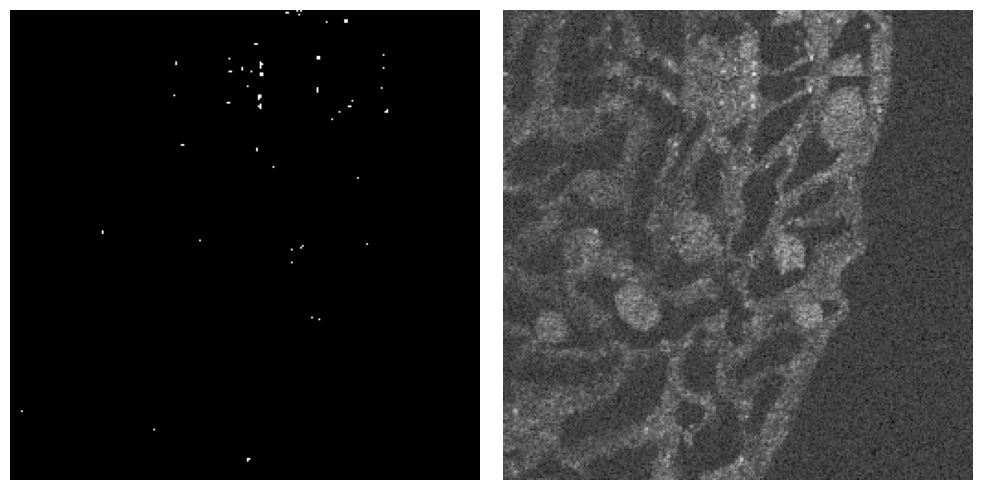

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [ ]:
env.show_last()


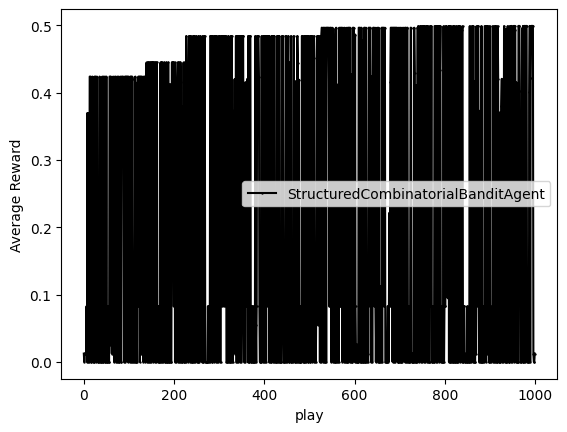

In [ ]:
plotResults(sample)